# Scraping from ATK

In this notebook, I'll go through the steps I went through to scrape the recipes from America's Test Kitchen (ATK). My goal was to scrape the recipe title, ingredient list, instructions, and recipe categories from as many recipes as possible. I'll first show how the initial list of URLs for each recipe was generated, then how the recipes themselves were scraped from the website.

This code was originally implemented in January 2025. Since then, the structure of the ATK website has changed, and this code no longer functions as a recipe scraper. To recreate this dataset, one would then need to write another scraper and have an active ATK subscription.

In [ ]:
from bs4 import BeautifulSoup
from selenium import webdriver
import pandas as pd
from tqdm import tqdm
from random import shuffle
import numpy as np

## Getting List of Recipe URLs

To obtain the list urls of the recipes, I go to the page associated with each category that ATK may assign to their recipes. I obtained this list by hand, and the scrape recipe urls from each of these category pages.

In [ ]:
from itertools import repeat

#List of categories
categories = ['main-courses','desserts-or-baked-goods','side-dishes','appetizers',
              'chicken','fruit','vegetables','pork','beef','fish-and-seafood','cheese','pasta','potatoes',
              'poultry','chocolate','beans','eggs-and-dairy','grains','rice','turkey','lamb',
              'gluten-free','vegetarian','paleo','vegan',
              'africa-and-middle-east','asia','europe','latin-america-and-caribbean','us-and-canada',
              'salads','condiments','breakfast-and-brunch','cakes','sauces','cookies','fruit-desserts','soups',
              'breads','sandwiches','beverages','stews','snacks','casseroles','dessert-pies','roasts','quick-breads',
              'puddings-custards-gelatins-and-souffles','frozen-desserts','savory-pies-and-tarts','brownies-and-bars',
              'pizza','tarts','candy','rubs','marinades']
links = ['https://www.americastestkitchen.com/recipes/'+x+'?p=27' for x in categories]
dictionary = dict(zip(categories, repeat(None)))
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
driver = webdriver.Chrome(options=options)

#Scraping the links for each category
for i in tqdm(range(len(links))):
    driver.get(links[i])
    recipe = driver.page_source
    soup = BeautifulSoup(recipe, 'html5lib')
    dummy = []
    for link in soup.find_all('li',class_="SearchCard_card__MLzqm"):
        dummy.append('https://www.americastestkitchen.com'+link.find('a').get('href'))
    dictionary[categories[i]]=dummy

recipe_links = list(set(np.concatenate(list(dictionary.values()))))
shuffle(recipe_links)

100%|██████████| 56/56 [01:23<00:00,  1.50s/it]


## Scraping Recipes

The urls from the above section are taken and the recipes are then scraped from each page. The recipe title, ingredients, and instructions are saved alongside the categories. 

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument("--headless=new")
driver = webdriver.Chrome(options=options)
labels = []
title = []
ingredients = []
instructions = []
broken_links = []

#Scraping the recipe information for each link obtained from the previous step. 
#If the link is broken, it is added to the broken_links list and skipped.
for i in tqdm(range(len(recipe_links))):
    driver.get(recipe_links[i])
    recipe = driver.page_source
    recipe_soup = BeautifulSoup(recipe,'html5lib')
    try:
        new_label = [text for text in recipe_soup.find('ul',class_='DocumentTags_list__Yy6KB').stripped_strings if 'ATK Staff Pick' not in text]
        new_title = recipe_soup.find('h1').get_text()
        new_ingredients = recipe_soup.find('div',class_="RecipeIngredientGroup_group__B3TTL").get_text(" ")
        new_instructions = recipe_soup.find('div',class_="RecipeInstructions_recipeInstructionsList__IyXH9").get_text().replace("\n"," ")
        
        labels.append(new_label)
        title.append(new_title)
        ingredients.append(new_ingredients)
        instructions.append(new_instructions)
    except:
        broken_links.append(recipe_links[i])
    recipe_soup.decompose()

## Collecting Scraped Data and Saving File

In [ ]:
#Filtering out the broken links and combining the labels obtained from the recipe page and the category page the recipe url was originally from.
#The final dataframe is created with the combined labels, title, ingredients and instructions.
filtered_links = [item for item in recipe_links if item not in broken_links]
processed_labels = [[x.lower().replace(" ","-").replace("&","and").replace(',','') for x in y] for y in labels]
website_labels = [[cat for cat in categories if links in dictionary[cat]] for links in filtered_links]
final_label = [list(set(np.concatenate([processed_labels[i],website_labels[i]]))) for i in range(len(processed_labels))]
df = pd.DataFrame((final_label,title,ingredients,instructions)).transpose()
df[3]=df[3].replace(r'\d\.','',regex=True)

In [ ]:
#Saving the recipes dataframe to a json file for use in the training of the model.
df.to_json("atk_recipes.json",index=False)

# Training with Classical Machine Learning Models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from heapq import nlargest
from recipe_preprocessing import preprocess_recipe

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import sklearn.metrics as skm

from wordcloud import WordCloud

In this section, I will show how a classical machine learning models are trained. The first section preprocesses the recipes and splits the dataset into train and test sets. The following sections show each how model is trained, alongside evaluations of each model. At the end, the most successful model is saved to be used later. 

## Preprocess Text

In [ ]:
categories = ['main-courses','desserts-or-baked-goods','side-dishes','appetizers',
                'chicken','fruit','vegetables','pork','beef','fish-and-seafood','cheese','pasta','potatoes',
                'poultry','chocolate','beans','eggs-and-dairy','grains','rice','turkey','lamb',
                'gluten-free','vegetarian','paleo','vegan',
                'africa-and-middle-east','asia','europe','latin-america-and-caribbean','us-and-canada',
                'salads','condiments','breakfast-and-brunch','cakes','sauces','cookies','fruit-desserts','soups',
                'breads','sandwiches','beverages','stews','snacks','casseroles','dessert-pies','roasts','quick-breads',
                'puddings-custards-gelatins-and-souffles','frozen-desserts','savory-pies-and-tarts','brownies-and-bars',
                'pizza','tarts','candy','rubs','marinades']

df = pd.read_json("americas_test_kitchen_recipes_larger.json")

abbreviated_labels = [[x for x in df[0].iloc[i] if x in categories] for i in range(len(df[0]))]
df[0]=abbreviated_labels
df = df[df[0].str.len() != 0]
text = [preprocess_recipe(x,y,z) for x,y,z in zip(df[1],df[2],df[3])]

X_train, X_test, y_train, y_test = train_test_split(text, abbreviated_labels, random_state=0,test_size=0.2)

mlb = MultiLabelBinarizer()
y_train_binarized = mlb.fit_transform(y_train)
y_test_binarized = mlb.transform(y_test)

vectorizer = TfidfVectorizer()

## MultinomialNB

In [ ]:
model = make_pipeline(vectorizer,MultiOutputClassifier(MultinomialNB(alpha=.0001,force_alpha=False)))
model.fit(X_train, y_train_binarized)
predicted_labels = model.predict(X_test)
print(skm.precision_recall_fscore_support(y_test_binarized,predicted_labels,average='micro'))

(0.7359884141926141, 0.603778068195319, 0.6633598746899882, None)


beef


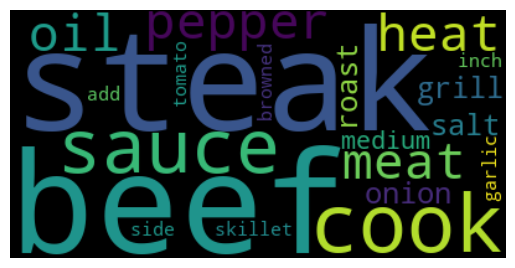

In [ ]:
feat_impts = [] 
for clf in model[1].estimators_:
    feat_impts.append(clf.feature_log_prob_)
classes_dictionary = dict(zip(mlb.classes_,np.arange(len(mlb.classes_))))
i = classes_dictionary['beef']
features=dict(zip(model[0].get_feature_names_out(),np.exp(feat_impts[i])[1]))
print(mlb.classes_[i])
wordcloud = WordCloud(relative_scaling=0).generate(' '.join(nlargest(20,features, key=features.get)))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))
classification_table=pd.DataFrame(skm.classification_report(y_test_binarized,predicted_labels,output_dict=True,zero_division=0
                                                           )).rename(columns=renaming_classes).transpose()
print(classification_table.to_string())

                                         precision    recall  f1-score  support
africa-and-middle-east                    0.750000  0.315789  0.444444     19.0
appetizers                                0.967742  0.218978  0.357143    137.0
asia                                      0.613333  0.528736  0.567901     87.0
beans                                     0.625000  0.463918  0.532544     97.0
beef                                      0.862944  0.787037  0.823245    216.0
beverages                                 0.923077  0.761905  0.834783     63.0
breads                                    0.593750  0.655172  0.622951     87.0
breakfast-and-brunch                      0.686047  0.491667  0.572816    120.0
brownies-and-bars                         0.739130  0.809524  0.772727     21.0
cakes                                     0.615894  0.869159  0.720930    107.0
candy                                     0.666667  0.571429  0.615385      7.0
casseroles                              

## Logistic Regression

In [ ]:
model = make_pipeline(vectorizer,MultiOutputClassifier(LogisticRegression(C=10,max_iter=1000)))
model.fit(X_train, y_train_binarized)
predicted_labels = model.predict(X_test)
print(skm.precision_recall_fscore_support(y_test_binarized,predicted_labels,average='micro'))

(0.8492506611813107, 0.6867054770108114, 0.7593772580963016, None)


beef


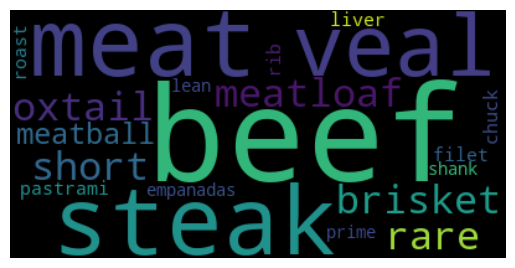

In [ ]:
feat_impts = [] 
for clf in model[1].estimators_:
    feat_impts.append(clf.coef_)
classes_dictionary = dict(zip(mlb.classes_,np.arange(len(mlb.classes_))))
i = classes_dictionary['beef']
features=dict(zip(model[0].get_feature_names_out(),feat_impts[i][0]))
print(mlb.classes_[i])
wordcloud = WordCloud(relative_scaling=0).generate(' '.join(nlargest(20,features, key=features.get)))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))
classification_table=pd.DataFrame(skm.classification_report(y_test_binarized,predicted_labels,output_dict=True,zero_division=0
                                                           )).rename(columns=renaming_classes).transpose()
print(classification_table.to_string())

                                         precision    recall  f1-score  support
africa-and-middle-east                    0.666667  0.105263  0.181818     19.0
appetizers                                0.960000  0.350365  0.513369    137.0
asia                                      0.813953  0.402299  0.538462     87.0
beans                                     0.721519  0.587629  0.647727     97.0
beef                                      0.965000  0.893519  0.927885    216.0
beverages                                 0.981132  0.825397  0.896552     63.0
breads                                    0.885246  0.620690  0.729730     87.0
breakfast-and-brunch                      0.850000  0.566667  0.680000    120.0
brownies-and-bars                         0.857143  0.571429  0.685714     21.0
cakes                                     0.918367  0.841121  0.878049    107.0
candy                                     0.750000  0.428571  0.545455      7.0
casseroles                              

## Random Forest Classifier

In [ ]:
model = make_pipeline(vectorizer,MultiOutputClassifier(RandomForestClassifier(n_estimators=100,n_jobs=-1)))
model.fit(X_train, y_train_binarized)
predicted_labels = model.predict(X_test)
print(skm.precision_recall_fscore_support(y_test_binarized,predicted_labels,average='micro'))

(0.9054113506379234, 0.48901033622430795, 0.635038185605184, None)


beef


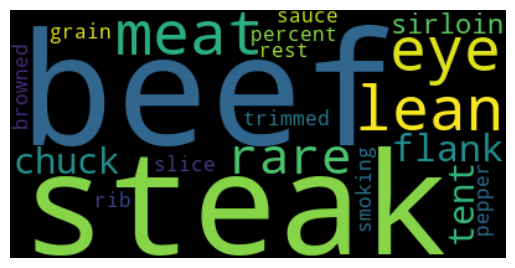

In [ ]:
feat_impts = [] 
for clf in model[1].estimators_:
    feat_impts.append(clf.feature_importances_)
classes_dictionary = dict(zip(mlb.classes_,np.arange(len(mlb.classes_))))
i = classes_dictionary['beef']
features=dict(zip(model[0].get_feature_names_out(),feat_impts[i]))
print(mlb.classes_[i])

wordcloud = WordCloud(relative_scaling=0).generate(' '.join(nlargest(20,features, key=features.get)))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))
classification_table=pd.DataFrame(skm.classification_report(y_test_binarized,predicted_labels,output_dict=True,zero_division=0
                                                           )).rename(columns=renaming_classes).transpose()
print(classification_table.to_string())

                                         precision    recall  f1-score  support
africa-and-middle-east                    1.000000  0.210526  0.347826     19.0
appetizers                                0.971429  0.248175  0.395349    137.0
asia                                      0.833333  0.172414  0.285714     87.0
beans                                     0.925926  0.257732  0.403226     97.0
beef                                      0.973333  0.675926  0.797814    216.0
beverages                                 0.978261  0.714286  0.825688     63.0
breads                                    0.961538  0.574713  0.719424     87.0
breakfast-and-brunch                      0.942308  0.408333  0.569767    120.0
brownies-and-bars                         0.916667  0.523810  0.666667     21.0
cakes                                     0.931507  0.635514  0.755556    107.0
candy                                     1.000000  0.428571  0.600000      7.0
casseroles                              

## Support Vector Classifier

In [ ]:
model = make_pipeline(vectorizer,MultiOutputClassifier(LinearSVC(C=2)))
model.fit(X_train, y_train_binarized)
predicted_labels = model.predict(X_test)
print(skm.precision_recall_fscore_support(y_test_binarized,predicted_labels,average='micro'))

(0.8306595365418895, 0.7197338719258644, 0.7712285168682368, None)


beef


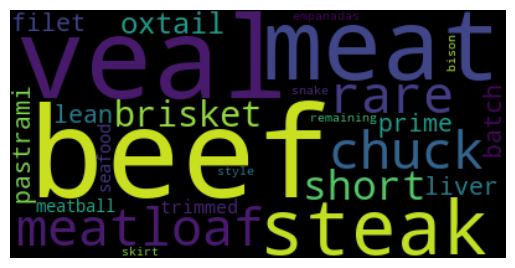

In [ ]:
feat_impts = [] 
for clf in model[1].estimators_:
    feat_impts.append(clf.coef_)

classes_dictionary = dict(zip(mlb.classes_,np.arange(len(mlb.classes_))))
i = classes_dictionary['beef']

features=dict(zip(model[0].get_feature_names_out(),feat_impts[i].flatten()))
print(mlb.classes_[i])

wordcloud = WordCloud(relative_scaling=0).generate(' '.join(nlargest(25,features, key=features.get)))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))
classification_table=pd.DataFrame(skm.classification_report(y_test_binarized,predicted_labels,output_dict=True,zero_division=0
                                                           )).rename(columns=renaming_classes).transpose()
print(classification_table.to_string())

                                         precision    recall  f1-score  support
africa-and-middle-east                    0.750000  0.315789  0.444444     19.0
appetizers                                0.800000  0.467153  0.589862    137.0
asia                                      0.774194  0.551724  0.644295     87.0
beans                                     0.717647  0.628866  0.670330     97.0
beef                                      0.948598  0.939815  0.944186    216.0
beverages                                 0.983051  0.920635  0.950820     63.0
breads                                    0.833333  0.689655  0.754717     87.0
breakfast-and-brunch                      0.819048  0.716667  0.764444    120.0
brownies-and-bars                         0.947368  0.857143  0.900000     21.0
cakes                                     0.904762  0.887850  0.896226    107.0
candy                                     0.833333  0.714286  0.769231      7.0
casseroles                              

## Saving Model

In [ ]:
model = make_pipeline(vectorizer,MultiOutputClassifier(LinearSVC(C=2)))
model.fit(X_train, y_train_binarized)

from joblib import dump
with open("svc_recipes.pkl", "wb") as f:
    dump(model, f, protocol=5)
with open("mlb.pkl", "wb") as f:
    dump(mlb, f, protocol=5)

# Fine Tuning Distilbert

## Importing Data and Modules

In [ ]:
%load_ext autoreload
%autoreload all

import numpy as np
import torch
import torch.optim as optim
import sklearn.metrics as skm
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, get_linear_schedule_with_warmup
from transformers import Trainer,TrainingArguments
from training import predict, train
from peft import get_peft_model, LoraConfig, TaskType, PeftModel
from datasets import Dataset


if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(device)

mps


In [ ]:
categories = ['main-courses','desserts-or-baked-goods','side-dishes','appetizers',
                'chicken','fruit','vegetables','pork','beef','fish-and-seafood','cheese','pasta','potatoes',
                'poultry','chocolate','beans','eggs-and-dairy','grains','rice','turkey','lamb',
                'gluten-free','vegetarian','paleo','vegan',
                'africa-and-middle-east','asia','europe','latin-america-and-caribbean','us-and-canada',
                'salads','condiments','breakfast-and-brunch','cakes','sauces','cookies','fruit-desserts','soups',
                'breads','sandwiches','beverages','stews','snacks','casseroles','dessert-pies','roasts','quick-breads',
                'puddings-custards-gelatins-and-souffles','frozen-desserts','savory-pies-and-tarts','brownies-and-bars',
                'pizza','tarts','candy','rubs','marinades']

df = pd.read_json("americas_test_kitchen_recipes_larger.json")

abbreviated_labels = [[x for x in df[0].iloc[i] if x in categories] for i in range(len(df[0]))]
df[0]=abbreviated_labels
df = df[df[0].str.len() != 0]
text = [preprocess_recipe(x,y,z) for x,y,z in zip(df[1],df[2],df[3])]

X_train, X_test, y_train, y_test = train_test_split(text, abbreviated_labels, random_state=0,test_size=0.2)

mlb = MultiLabelBinarizer()
y_train_binarized = mlb.fit_transform(y_train)
y_test_binarized = mlb.transform(y_test)

num_labels = len(y_train_binarized[0])

## Creating Datasets

In [ ]:
MODEL_NAME_OR_PATH = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_OR_PATH, use_fast=True)
train_tokenized = tokenizer(list(X_train),padding=True,truncation=True,max_length=512)
val_tokenized = tokenizer(list(X_test),padding=True,truncation=True,max_length=512)

train_dict = {
    "input_ids": train_tokenized["input_ids"],
    "attention_mask": train_tokenized["attention_mask"],
    "labels": y_train_binarized.tolist(),
}

test_dict = {
    "input_ids": val_tokenized["input_ids"],
    "attention_mask": val_tokenized["attention_mask"],
    "labels": y_test_binarized.tolist(),
}

train_dataset = Dataset.from_dict(train_dict)
val_dataset = Dataset.from_dict(test_dict)

from datasets import Sequence, Value

train_dataset = train_dataset.cast_column("labels", Sequence(Value("float32")))
val_dataset = val_dataset.cast_column("labels", Sequence(Value("float32")))

collator = DataCollatorWithPadding(tokenizer)

Casting the dataset:   0%|          | 0/10091 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2523 [00:00<?, ? examples/s]

## Loading Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_OR_PATH,
                                                           num_labels=num_labels,
                                                           problem_type="multi_label_classification")

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin"],
)
model = get_peft_model(model, lora_config)

model.to(device)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model.print_trainable_parameters()

trainable params: 781,112 || all params: 67,777,648 || trainable%: 1.1525


## Training Model

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = (logits > 0).astype(int)  # threshold at 0 since pre-sigmoid
    return {
        "f1_micro": skm.f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": skm.f1_score(labels, preds, average="macro", zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="deberta_model/",
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=len(train_dataset) // 15,              # replaces your manual warmup steps calculation
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    bf16=True,
    tf32=True,                     # mixed precision — free speedup on your 3060
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,        # your DataCollatorWithPadding
)

trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.191482,0.186762,0.113540,0.010538
2,0.133842,0.121951,0.505803,0.177965
3,0.101573,0.098456,0.633739,0.388983
4,0.093290,0.088776,0.660275,0.461429
5,0.085903,0.085047,0.676426,0.502812
6,0.078498,0.080876,0.700125,0.536170
7,0.080711,0.077963,0.709315,0.569131
8,0.077438,0.076289,0.717232,0.588071
9,0.072205,0.074364,0.727065,0.617531
10,0.070534,0.073215,0.732453,0.630873


TrainOutput(global_step=4740, training_loss=0.10351199580647272, metrics={'train_runtime': 1841.6067, 'train_samples_per_second': 82.192, 'train_steps_per_second': 2.574, 'total_flos': 2.043344893943808e+16, 'train_loss': 0.10351199580647272, 'epoch': 15.0})

## Loading Previously Trained Model

In [ ]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)

# Then load the LoRA weights on top
# Point to whichever checkpoint you want
model = PeftModel.from_pretrained(base_model, "checkpoint-9480/")
model.to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = (logits > 0).astype(int)  # threshold at 0 since pre-sigmoid
    return {
        "f1_micro": skm.f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": skm.f1_score(labels, preds, average="macro", zero_division=0),
    }
training_args = TrainingArguments(
    output_dir="model/",
    num_train_epochs=10,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=len(train_dataset) // 10,              # replaces your manual warmup steps calculation
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    # bf16=True,
    # tf32=True,                     # mixed precision — free speedup on your 3060
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=collator,        # your DataCollatorWithPadding
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Evaluating Model Performance

In [ ]:
probabilities_val = trainer.predict(val_dataset).predictions
predicted_labels = np.where(probabilities_val>0,1,0)

/Users/davidmayrhofer/Documents/Python/Machine Learning/Recipes Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


In [ ]:
logits = trainer.predict(val_dataset).predictions
# labels = predictions.label_ids

best_thresholds = []
for i in range(num_labels):
    best_t, best_f1 = 0, 0
    for t in np.linspace(-3, 3, 61):  # search in logit space
        preds = (logits[:, i] > t).astype(int)
        f1 = skm.f1_score(y_test_binarized[:,i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds.append(best_t)

best_thresholds = np.array(best_thresholds)
final_preds = (logits > best_thresholds).astype(int)

/Users/davidmayrhofer/Documents/Python/Machine Learning/Recipes Project/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [ ]:
renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))

classification_table = pd.DataFrame(
    skm.classification_report(
        y_test_binarized,
        predicted_labels,
        output_dict=True,
        zero_division=0)
).rename(columns=renaming_classes).transpose()

print(classification_table.to_string())

                                         precision    recall  f1-score  support
africa-and-middle-east                    0.777778  0.350000  0.482759     20.0
appetizers                                0.757143  0.424000  0.543590    125.0
asia                                      0.666667  0.658228  0.662420     79.0
beans                                     0.777778  0.693694  0.733333    111.0
beef                                      0.929293  0.901961  0.915423    204.0
beverages                                 0.883333  0.841270  0.861789     63.0
breads                                    0.758065  0.661972  0.706767     71.0
breakfast-and-brunch                      0.850877  0.713235  0.776000    136.0
brownies-and-bars                         0.687500  0.647059  0.666667     17.0
cakes                                     0.888000  0.932773  0.909836    119.0
candy                                     1.000000  0.384615  0.555556     13.0
casseroles                              

# Comparing Fine Tuned Neural Network with SVC

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import make_pipeline

vectorizer = TfidfVectorizer()
model = make_pipeline(vectorizer,MultiOutputClassifier(LinearSVC(C=2)))
model.fit(X_train, y_train_binarized)
predicted_labels_svc = model.predict(X_test)

renaming_classes = dict(zip(np.arange(len(mlb.classes_)).astype(str),mlb.classes_))
classification_table_svc=pd.DataFrame(skm.classification_report(y_test_binarized,predicted_labels_svc,output_dict=True,zero_division=0
                                                           )).rename(columns=renaming_classes).transpose()
# print(classification_table_svc.to_string())

In [ ]:
decision_scores = np.array([clf.decision_function(vectorizer.transform(X_test)) for clf in model[1].estimators_]).T

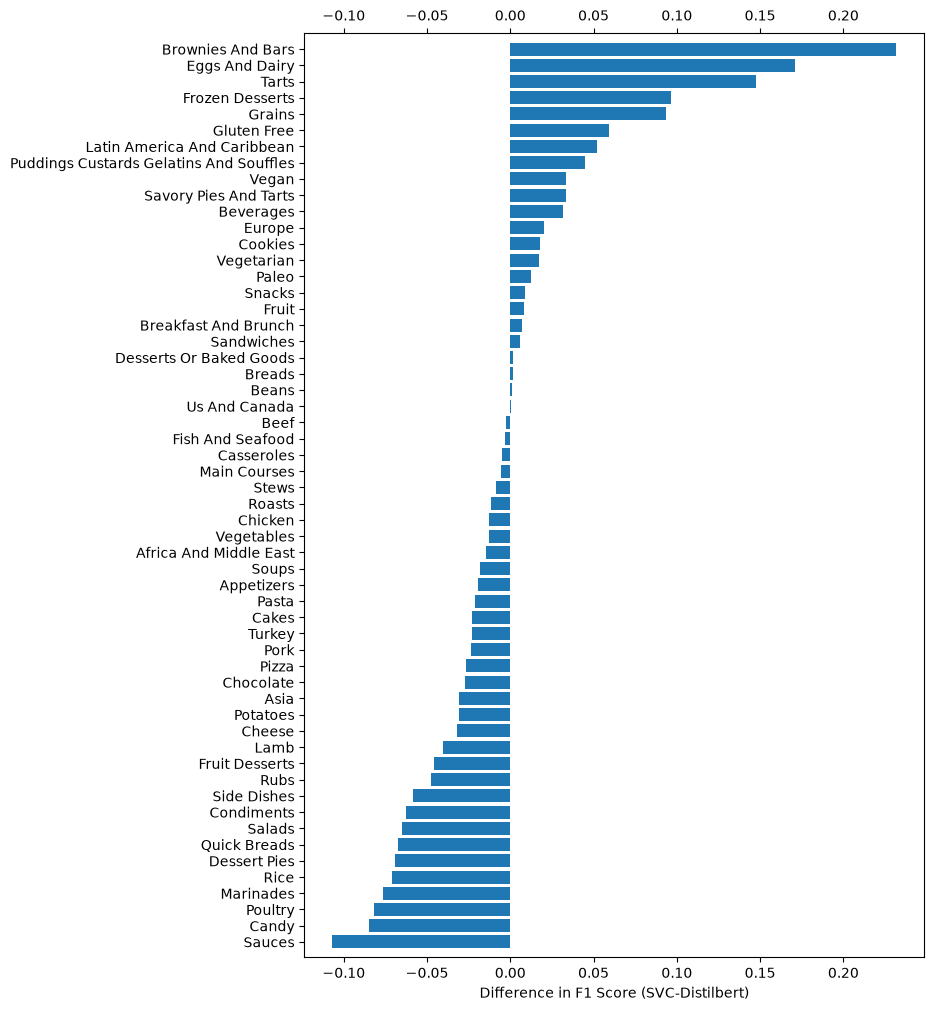

In [ ]:
fig, ax = plt.subplots(figsize=(8, 12))
delta_f1 = (((classification_table_svc-classification_table))[:-4]).sort_values(by='f1-score')['f1-score']
tags = delta_f1.index.str.replace('-',' ').str.title()
ax.barh(tags,delta_f1)
ax.margins(y=.01)
ax.tick_params(top=True, labeltop=True, bottom=True, labelbottom=True)
ax.set_xlabel('Difference in F1 Score (SVC-Distilbert)');
